# Single RNN Perturbation Analysis

This notebook reproduces the perturbation experiments for the original single-RNN model.

The analysis includes the dynamic perturbation trajectory, Stage 2 transition error, frozen-state behavior, fixed-route error analysis, and behavioral-state changes after perturbation.

In [1]:
import os
import sys
from pathlib import Path

current_dir = Path.cwd().resolve()

if (current_dir / "perturbation_testing.py").exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / "perturbation_testing.py").exists():
    PROJECT_ROOT = current_dir.parent
else:
    raise RuntimeError(f"Could not locate project root from {current_dir}")

PROJECT_ROOT = str(PROJECT_ROOT)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

os.chdir(PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)
print("Working directory:", os.getcwd())

Project root: /Users/neelprabhakar/Python /Research/RNN/RNN_small_hippocampal_model
Working directory: /Users/neelprabhakar/Python /Research/RNN/RNN_small_hippocampal_model


In [2]:
%load_ext autoreload
%autoreload 2

import random
import numpy as np
import torch
import matplotlib.pyplot as plt

import perturbation_testing as pt
import figure2_generation as f2g
import manifold_visualization as mv

print("Imports successful")

/Users/neelprabhakar/Python /.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports successful


## Experiment Configuration

Set the random seed and initialize the original single-RNN model used for the perturbation experiment.

In [3]:
SEED = 42
TOTAL_PERTURBATIONS = 1000

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print("Seed:", SEED)
print("Device:", device)
print("Total perturbations:", TOTAL_PERTURBATIONS)

Seed: 42
Device: mps
Total perturbations: 1000


## Load Original RNN Model

Load the saved post-Stage-1 RNN checkpoint used to generate the original transition dictionaries.

In [4]:
model = pt.small_model.RNN().to(device)

checkpoint = torch.load(os.path.join(PROJECT_ROOT, "post_stage1_model_sd42.pt"), map_location=device, weights_only=True)

model.load_state_dict(checkpoint)
model.eval()

print("Original RNN model loaded.")

Original RNN model loaded.


## Load Original Route and Transition Dictionaries

Load the fixed route and the original neural, behavioral, and joint neural-behavioral transition dictionaries.

In [5]:
route_seq = np.load(os.path.join(PROJECT_ROOT, "route_sequence_min100.npy"), allow_pickle=True)

with np.load(pt.ORIGINAL_N_PATH, allow_pickle=True) as original_n_file:
    og_n_dict = original_n_file["neural_state_dict"].item()

with np.load(pt.ORIGINAL_B_PATH, allow_pickle=True) as original_b_file:
    og_b_dict = original_b_file["b_transition_dict"].item()

with np.load(pt.ORIGINAL_PAIR_PATH, allow_pickle=True) as original_pair_file:
    og_pair_dict = original_pair_file["pair_dict"].item()

print("Fixed route length:", len(route_seq))
print("Original neural states:", len(og_n_dict))
print("Original behavioral states:", len(og_b_dict))
print("Original pair states:", len(og_pair_dict))

Fixed route length: 50
Original neural states: 2274
Original behavioral states: 400
Original pair states: 6167


## Run Single-RNN Perturbation Experiment

Run 1,000 neuron perturbations and update the behavioral, neural, and joint transition dictionaries while recording Stage 2 error.

In [6]:
new_b_t_dict, new_n_t_dict, new_pair_t_dict, stage_2_error_his = pt.run_pertubation(model, og_b_dict, og_pair_dict, total_num_pertubations=TOTAL_PERTURBATIONS, sd=SEED)

print("Perturbation experiment complete.")
print("Stage 2 steps:", len(stage_2_error_his))

Perturbations per neuron: [100 100 100 100 100 100 100 100 100 100]
Total perturbations: 1000
[Log] Perturbations complete
Perturbation experiment complete.
Stage 2 steps: 1000


## Stage 2: Dynamic Perturbation Error

Stage 2 follows the evolving perturbed trajectory and compares transition probabilities against the original transition model at each perturbation step.

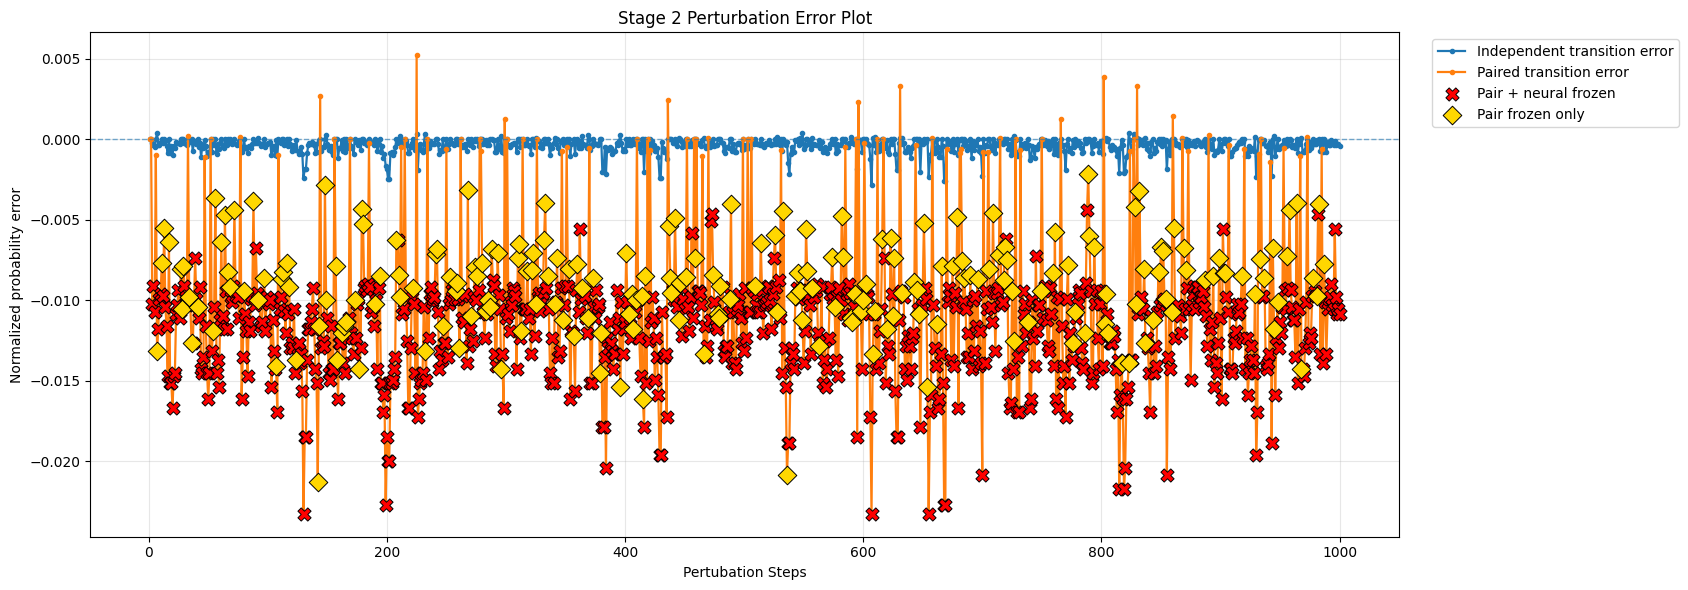

Mean normalized error: -0.00038716746825456474
Median normalized error: -0.00031048700403539113
Maximum normalized error: 0.00039588655644919073
Minimum normalized error: -0.0028507126781695423


In [7]:
pt.plot_stage2_normalized_error_over_time(stage_2_error_his, title="Stage 2 Perturbation Error Plot", x_label="Pertubation Steps", include_pair_error=True, save_path=None)

## Stage 3: Fixed-Route Error

Stage 3 evaluates the same fixed original route before and after perturbation.

First, the route is evaluated using the original transition dictionaries.

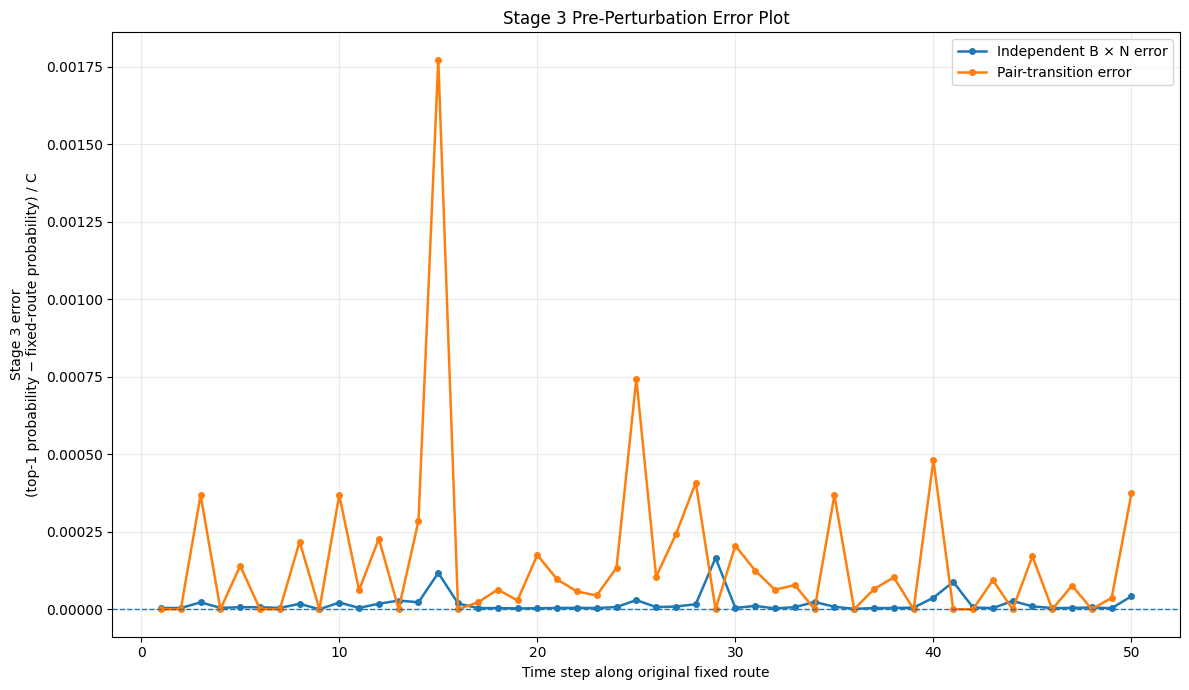

In [8]:
pre_perturb_stage_3_error_his = pt.calc_stage3_error(route_seq, og_b_dict, og_n_dict, og_pair_dict)
pt.plot_stage3_error( pre_perturb_stage_3_error_his, title="Stage 3 Pre-Perturbation Error Plot", save_path=None)

### Post-Perturbation Fixed-Route Error

The same fixed route is evaluated again using the transition dictionaries updated during the perturbation experiment.

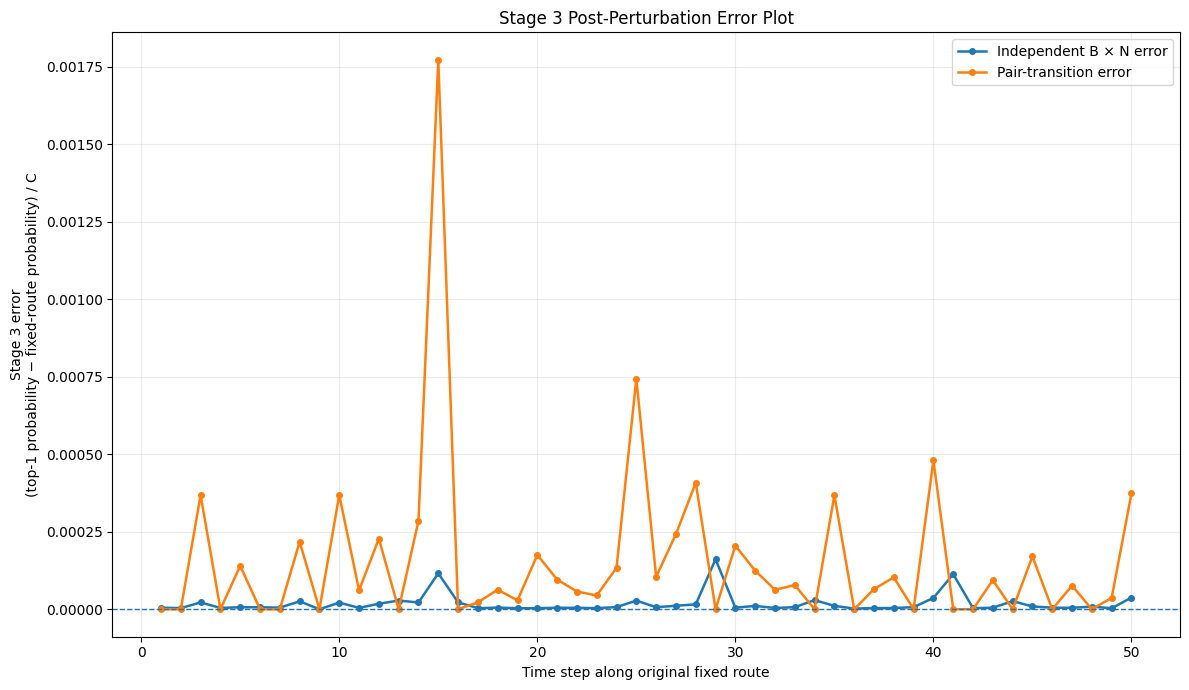

In [9]:
post_perturb_stage_3_error_his = pt.calc_stage3_error(route_seq, new_b_t_dict, new_n_t_dict, new_pair_t_dict)
pt.plot_stage3_error( post_perturb_stage_3_error_his, title="Stage 3 Post-Perturbation Error Plot", save_path=None)

## Neural and Behavioral State Distributions

Compare the outgoing transition distributions of the original transition dictionaries with the dictionaries updated during the perturbation experiment.

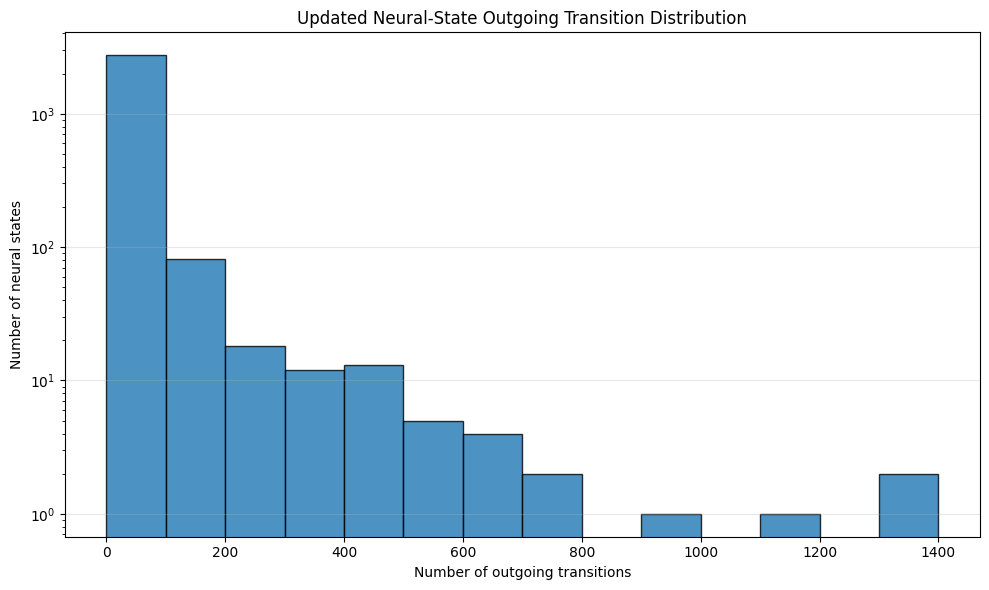

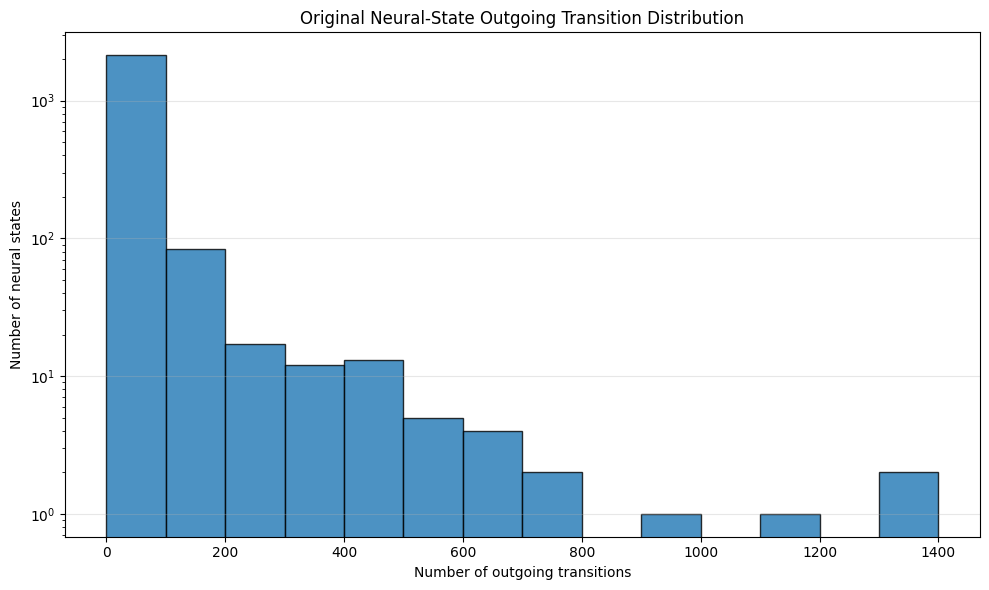

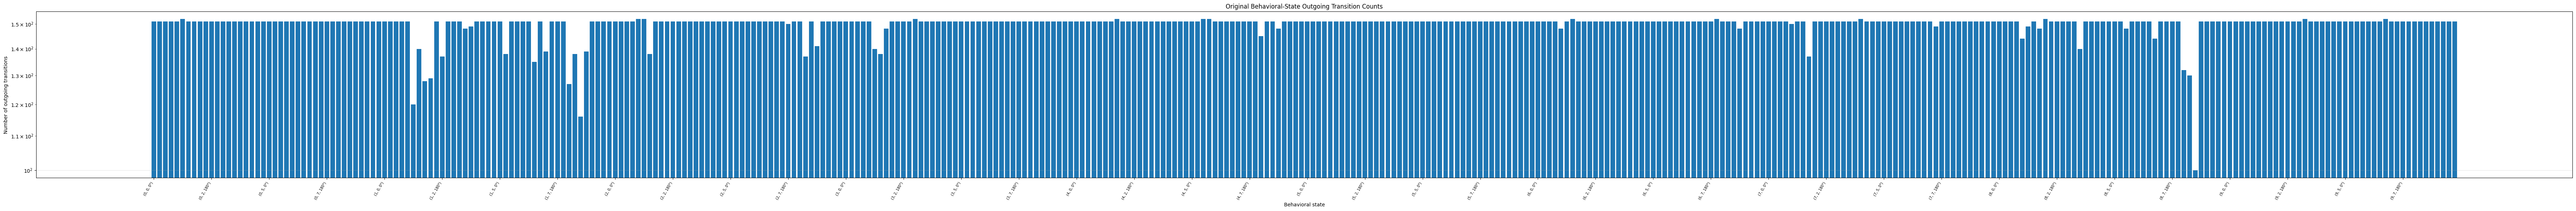

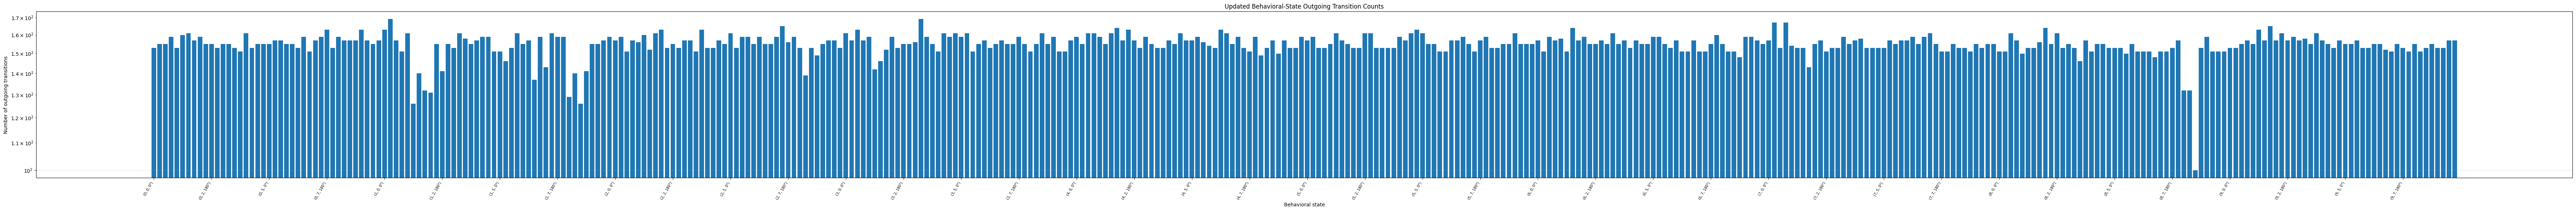

{(2, 5, 2): 159,
 (1, 6, 3): 159,
 (0, 7, 2): 163,
 (0, 5, 0): 155,
 (3, 7, 1): 155,
 (2, 6, 0): 155,
 (5, 9, 0): 161,
 (2, 8, 2): 153,
 (1, 8, 3): 141,
 (0, 4, 2): 155,
 (0, 7, 3): 153,
 (0, 9, 1): 157,
 (0, 9, 0): 163,
 (0, 5, 2): 157,
 (0, 3, 1): 155,
 (0, 5, 1): 157,
 (1, 2, 0): 131,
 (2, 2, 3): 153,
 (4, 7, 1): 153,
 (2, 4, 1): 153,
 (7, 6, 0): 157,
 (8, 2, 0): 164,
 (6, 1, 0): 158,
 (7, 3, 2): 155,
 (8, 6, 1): 151,
 (6, 5, 2): 155,
 (6, 7, 0): 151,
 (6, 6, 3): 157,
 (8, 9, 1): 151,
 (8, 9, 0): 159,
 (6, 9, 1): 159,
 (9, 7, 2): 153,
 (9, 5, 2): 157,
 (9, 4, 3): 157,
 (9, 5, 0): 155,
 (8, 2, 2): 161,
 (9, 5, 3): 153,
 (8, 2, 1): 155,
 (9, 2, 3): 159,
 (9, 1, 0): 155,
 (8, 0, 3): 157,
 (5, 0, 1): 159,
 (0, 1, 0): 153,
 (0, 3, 3): 151,
 (0, 4, 3): 155,
 (0, 7, 1): 159,
 (0, 4, 0): 161,
 (0, 8, 1): 157,
 (2, 6, 2): 155,
 (3, 2, 1): 153,
 (5, 1, 3): 155,
 (4, 3, 1): 155,
 (6, 4, 3): 155,
 (3, 4, 3): 161,
 (4, 0, 3): 161,
 (3, 0, 0): 161,
 (3, 0, 1): 157,
 (5, 1, 0): 155,
 (4, 1, 3): 16

In [11]:
pt.graph_neural_distribution(new_n_t_dict, title="Updated Neural-State Outgoing Transition Distribution")
pt.graph_neural_distribution(og_n_dict, title="Original Neural-State Outgoing Transition Distribution")
pt.graph_behavioral_distribution(og_b_dict, title="Original Behavioral-State Outgoing Transition Counts", collapse_headings=False)
pt.graph_behavioral_distribution(new_b_t_dict, title="Updated Behavioral-State Outgoing Transition Counts", collapse_headings=False)